# Modeling — HOG + Linear SVM

**Purpose:** We build the strict modeling manifest, run the tuned RGB HOG + Linear SVM baseline, and inspect the selected classical model cleanly.

**Notebook Rules**
- We keep logic inside `src/`.
- We use a manual grid search over a fixed, explicit search space.
- We select the final classical baseline using **validation macro F1**.



In [1]:
# We set up the project path, import the shared config and utilities, and print the main project summary.

from pathlib import Path
import sys

currentDir = Path.cwd().resolve()
projectRoot = currentDir.parent if currentDir.name == "notebooks" else currentDir

if str(projectRoot) not in sys.path:
    sys.path.append(str(projectRoot))

from src.config import projectConfig
from src.utils import ensureProjectDirs, printProjectSummary, setGlobalSeed, applyPlotStyle

setGlobalSeed(projectConfig.seed)
ensureProjectDirs(projectConfig)
applyPlotStyle()
printProjectSummary(projectConfig)


projectRoot: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis
seed: 27
device: mps
imageDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/JPEGImages
annotationDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/Annotations
splitFilePath: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/train_val_test_split.txt
classFilePath: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/class_definitions.txt
cropsDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataProcessed/crops
metricsDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/metrics


### Strict Modeling Manifest

We first rebuild the strict modeling manifest so the classical baseline trains only on the leakage-aware crop list.


In [2]:
# We build the strict modeling manifest and collect the saved artifact paths.

import pandas as pd

from src.data import runModelingManifestBuilder

modelingResult = runModelingManifestBuilder(projectConfig)
modelingSummary = modelingResult["modelingSummary"]
modelingSavedPathDict = modelingResult["savedPathDict"]

modelingSummaryDf = pd.DataFrame(
    {
        "metricName": list(modelingSummary.keys()),
        "metricValue": list(modelingSummary.values()),
    }
)

modelingSummaryDf


,metricName,metricValue
0,rawCropCount,1584
1,strictModelingCropCount,1580
2,excludedDuplicateCropCount,4
3,excludedCrossSplitDuplicateCropCount,2
4,strictUniqueSourceImageCount,1061
5,strictTrainCropCount,1097
6,strictValCropCount,245
7,strictTestCropCount,238


### RGB HOG Baseline Tuning Plan

We now run a focused **30-trial** manual grid search for the classical baseline.

We keep the search centered around the already strong HOG region and test:
- three image sizes
- five Linear SVM `C` values
- two HOG orientation settings
- RGB HOG only

This gives a strong but still controlled classical baseline search.


In [ ]:
# We define the final 30-trial RGB HOG + Linear SVM search space.

hogLinearSvmSearchSpace = {
    "imageSizeList": [128, 144, 160],
    "cValueList": [0.001, 0.003,0.007, 0.01, 0.03],
    "pixelsPerCellList": [(8, 8), (16, 16)],
    "orientationsList": [9],
    "colorModeList": ["rgb"],
}

hogLinearSvmSearchSpace


{'imageSizeList': [128, 144, 160],
 'cValueList': [0.001, 0.003, 0.007, 0.01, 0.03],
 'pixelsPerCellList': [(8, 8), (16, 16)],
 'orientationsList': [9],
 'colorModeList': ['rgb']}

### Train the Tuned Classical Baseline

This cell runs the complete classical baseline search and saves the selected best artifacts. The later inspection cells read the saved outputs from disk.


In [4]:
# We run the tuned RGB HOG + Linear SVM baseline and keep the saved artifact paths.

from src.models import runTunedHogLinearSvmBaseline

baselineResult = runTunedHogLinearSvmBaseline(
    projectConfig=projectConfig,
    searchSpace=hogLinearSvmSearchSpace,
    svmTol=1e-3,
    svmMaxIter=10000,
    verbose=True,
)

baselineSavedPathDict = baselineResult["savedPathDict"]

print("Tuned RGB HOG + Linear SVM baseline completed.")
print("Saved files:")
for tableName, outputPath in baselineSavedPathDict.items():
    print(f"{tableName}: {outputPath}")


[HOG cache] Setting 1/6 | imageSize=128 | pixelsPerCell=(8, 8) | orientations=9 | colorMode=rgb
[HOG cache] Setting 2/6 | imageSize=128 | pixelsPerCell=(16, 16) | orientations=9 | colorMode=rgb
[HOG cache] Setting 3/6 | imageSize=144 | pixelsPerCell=(8, 8) | orientations=9 | colorMode=rgb
[HOG cache] Setting 4/6 | imageSize=144 | pixelsPerCell=(16, 16) | orientations=9 | colorMode=rgb
[HOG cache] Setting 5/6 | imageSize=160 | pixelsPerCell=(8, 8) | orientations=9 | colorMode=rgb
[HOG cache] Setting 6/6 | imageSize=160 | pixelsPerCell=(16, 16) | orientations=9 | colorMode=rgb
[HOG tuning] Trial 1/30 | imageSize=128 | pixelsPerCell=(8, 8) | orientations=9 | colorMode=rgb | C=0.001
[HOG tuning] Trial 2/30 | imageSize=128 | pixelsPerCell=(8, 8) | orientations=9 | colorMode=rgb | C=0.003
[HOG tuning] Trial 3/30 | imageSize=128 | pixelsPerCell=(8, 8) | orientations=9 | colorMode=rgb | C=0.007
[HOG tuning] Trial 4/30 | imageSize=128 | pixelsPerCell=(8, 8) | orientations=9 | colorMode=rgb | C=

### Selected Baseline Configuration

We load the saved configuration and inspect the selected best HOG + Linear SVM setting.


In [5]:
# We read the saved best-configuration JSON and convert the selected settings into a compact table.

import json

with open(baselineSavedPathDict["configPath"], "r", encoding="utf-8") as jsonFile:
    baselineConfig = json.load(jsonFile)

bestConfig = baselineConfig["bestConfig"]
bestValMetrics = baselineConfig["bestValMetrics"]
bestTrialMeta = baselineConfig["bestTrialMeta"]

bestConfigSummaryDf = pd.DataFrame(
    {
        "settingName": [
            "imageSize",
            "cValue",
            "pixelsPerCell",
            "orientations",
            "colorMode",
            "valMacroF1",
            "valMacroRecall",
            "valWeightedF1",
            "valAccuracy",
            "hadConvergenceWarning",
            "rankBySelection",
        ],
        "settingValue": [
            bestConfig["imageSize"],
            bestConfig["cValue"],
            str(tuple(bestConfig["pixelsPerCell"])),
            bestConfig["orientations"],
            bestConfig["colorMode"],
            bestValMetrics["macroF1"],
            bestValMetrics["macroRecall"],
            bestValMetrics["weightedF1"],
            bestValMetrics["accuracy"],
            bestTrialMeta["hadConvergenceWarning"],
            bestTrialMeta["rankBySelection"],
        ],
    }
)

bestConfigSummaryDf


,settingName,settingValue
0,imageSize,144
1,cValue,0.007
2,pixelsPerCell,"(16, 16)"
3,orientations,9
4,colorMode,rgb
5,valMacroF1,0.695655
6,valMacroRecall,0.705806
7,valWeightedF1,0.724684
8,valAccuracy,0.722449
9,hadConvergenceWarning,0


### Strongest Baseline Trials

We inspect the strongest tuning trials so we can see whether the selected winner is clearly best or whether several nearby configurations perform similarly.


In [6]:
# We read the saved tuning summary and inspect the strongest RGB HOG + Linear SVM trials.

tuningSummaryDf = pd.read_csv(baselineSavedPathDict["tuningSummaryPath"])
tuningSummaryDf.head(10)


,trialNumber,featureCacheKey,imageSize,pixelsPerCellX,pixelsPerCellY,pixelsPerCellLabel,orientations,colorMode,cValue,svmTol,...,trainMacroRecall,trainMacroF1,trainWeightedF1,valAccuracy,valMacroPrecision,valMacroRecall,valMacroF1,valWeightedF1,isSelectionEligible,rankBySelection
0,18,size144__ppc16x16__ori9__colorrgb,144,16,16,16x16,9,rgb,0.007,0.001,...,0.987679,0.987993,0.985493,0.722449,0.695445,0.705806,0.695655,0.724684,1,1
1,1,size128__ppc8x8__ori9__colorrgb,128,8,8,8x8,9,rgb,0.001,0.001,...,0.992448,0.992310,0.990891,0.714286,0.683745,0.703669,0.690254,0.718193,1,2
2,19,size144__ppc16x16__ori9__colorrgb,144,16,16,16x16,9,rgb,0.010,0.001,...,0.989397,0.989494,0.987288,0.714286,0.687955,0.699909,0.688828,0.716819,1,3
3,11,size144__ppc8x8__ori9__colorrgb,144,8,8,8x8,9,rgb,0.001,0.001,...,0.996885,0.997123,0.996359,0.722449,0.680270,0.695693,0.686904,0.724650,1,4
4,7,size128__ppc16x16__ori9__colorrgb,128,16,16,16x16,9,rgb,0.003,0.001,...,0.960980,0.960902,0.953790,0.714286,0.673501,0.705993,0.684097,0.718069,1,5
5,14,size144__ppc8x8__ori9__colorrgb,144,8,8,8x8,9,rgb,0.010,0.001,...,1.000000,1.000000,1.000000,0.710204,0.679291,0.692196,0.683088,0.712180,1,6
6,8,size128__ppc16x16__ori9__colorrgb,128,16,16,16x16,9,rgb,0.007,0.001,...,0.982933,0.983349,0.980023,0.714286,0.675799,0.696420,0.682218,0.718717,1,7
7,17,size144__ppc16x16__ori9__colorrgb,144,16,16,16x16,9,rgb,0.003,0.001,...,0.970525,0.969977,0.964684,0.706122,0.673741,0.696739,0.680561,0.709452,1,8
8,9,size128__ppc16x16__ori9__colorrgb,128,16,16,16x16,9,rgb,0.010,0.001,...,0.984732,0.985475,0.982745,0.714286,0.673924,0.697048,0.680473,0.719773,1,9
9,12,size144__ppc8x8__ori9__colorrgb,144,8,8,8x8,9,rgb,0.003,0.001,...,1.000000,1.000000,1.000000,0.710204,0.669577,0.687597,0.676860,0.712452,1,10


### Train, Validation, and Test Comparison on HOG + Linear SVM

We now inspect the saved train, validation, and test metric table of the selected classical baseline.


In [7]:
# We read the saved metric summary table so we can compare train, validation, and test performance directly.

metricSummaryDf = pd.read_csv(baselineSavedPathDict["metricSummaryPath"])
metricSummaryDf


,metricName,trainValue,valValue,testValue
0,accuracy,0.985415,0.722449,0.743697
1,macroPrecision,0.988471,0.695445,0.764740
2,macroRecall,0.987679,0.705806,0.758152
3,macroF1,0.987993,0.695655,0.760474
4,weightedF1,0.985493,0.724684,0.742973


### Validation Confusion Matrix

We inspect the validation confusion matrix of the selected classical baseline because validation macro F1 is the model-selection criterion.


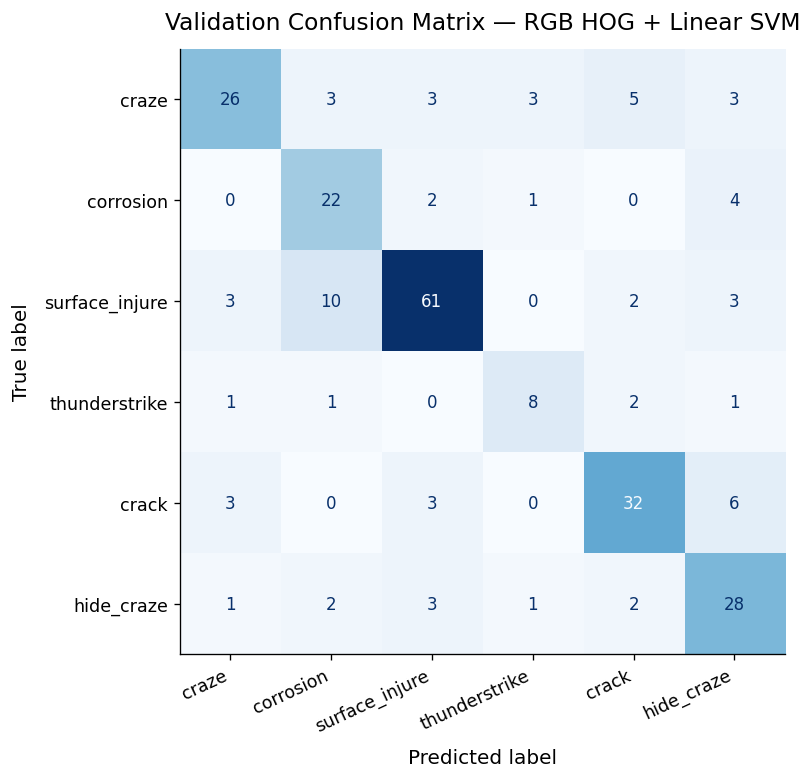

In [8]:
# We read the saved validation predictions and display the validation confusion matrix.

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

valPredictionDf = pd.read_csv(baselineSavedPathDict["valPredictionPath"])

valConfusionMatrix = confusion_matrix(
    valPredictionDf["className"],
    valPredictionDf["predictedClassName"],
    labels=projectConfig.classNames,
)

fig, ax = plt.subplots(figsize=(8.2, 6.6))

displayObject = ConfusionMatrixDisplay(
    confusion_matrix=valConfusionMatrix,
    display_labels=projectConfig.classNames,
)

displayObject.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format="d",
)

ax.set_title("Validation Confusion Matrix — RGB HOG + Linear SVM", pad=12)
ax.grid(False)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


### Test Confusion Matrix

We inspect the final test confusion matrix of the selected classical baseline after model selection is already complete.


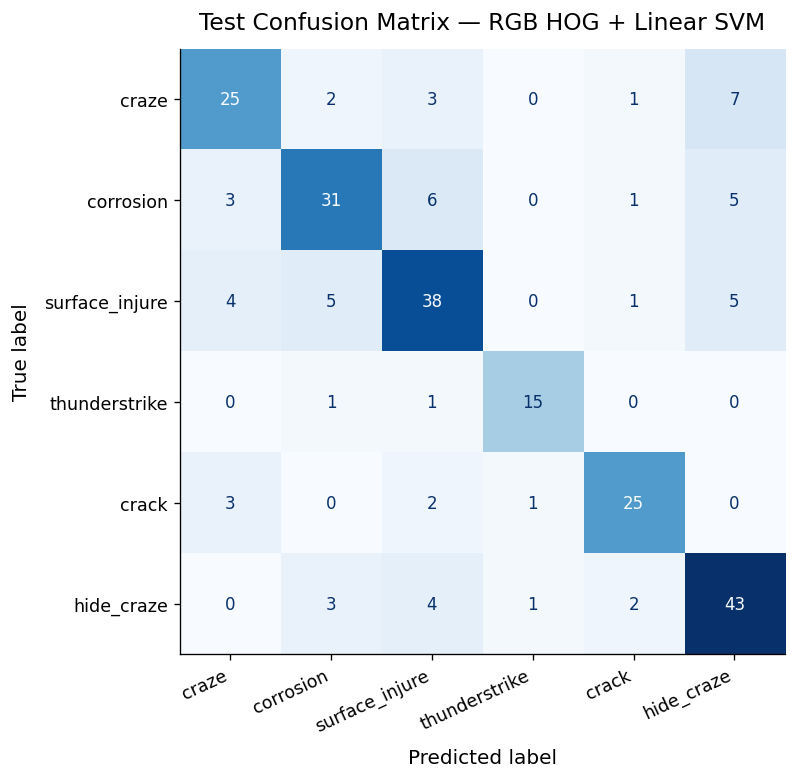

In [9]:
# We read the saved test predictions and display the final test confusion matrix.

testPredictionDf = pd.read_csv(baselineSavedPathDict["testPredictionPath"])

testConfusionMatrix = confusion_matrix(
    testPredictionDf["className"],
    testPredictionDf["predictedClassName"],
    labels=projectConfig.classNames,
)

fig, ax = plt.subplots(figsize=(8.2, 6.6))

displayObject = ConfusionMatrixDisplay(
    confusion_matrix=testConfusionMatrix,
    display_labels=projectConfig.classNames,
)

displayObject.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format="d",
)

ax.set_title("Test Confusion Matrix — RGB HOG + Linear SVM", pad=12)
ax.grid(False)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


### Classical Baseline Conclusion

The RGB HOG + Linear SVM model gives us a tuned classical benchmark after leakage-aware training and validation-based model selection.

The train/validation/test comparison table shows how strongly the selected classical model fits the seen data and how well it generalizes to unseen data. The tuning summary also shows whether the selected configuration is clearly best or whether several nearby configurations are similarly competitive. The validation and test confusion matrices then reveal which classes remain difficult for this handcrafted-feature approach.

This classical baseline now acts as the reference point for the later neural models: the MLP, our own CNN, and the pretrained transfer-learning model.


### Linear SVM Macro F1 vs Regularization Strength

We now inspect how macro F1 changes across the tested `C` values for the selected RGB HOG feature setting in the final focused Linear SVM search.  
To keep both the strong training fit and the lower validation/test scores readable, we again use a broken y-axis.

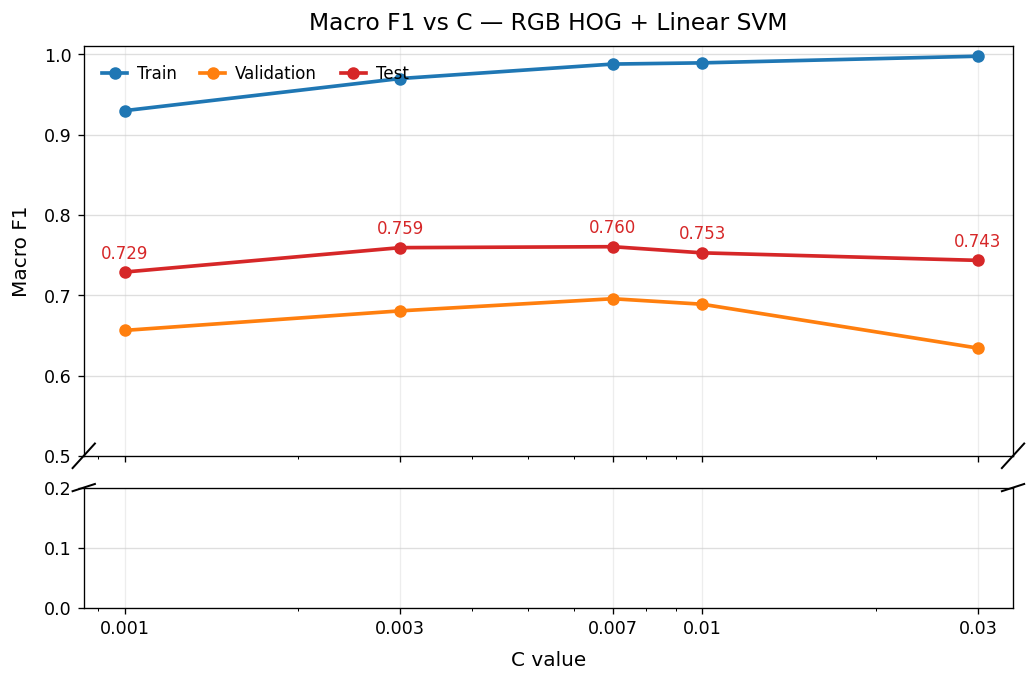

In [10]:
# We plot train, validation, and test macro F1 across C values for the selected Linear SVM feature setting
# using a clean broken y-axis with two solid rectangular panels.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score

from src.models.baselineModel import buildHogParamDict, buildSubsetFeatures

selectedImageSize = int(bestConfig["imageSize"])
selectedPixelsPerCell = (
    int(bestConfig["pixelsPerCell"][0]),
    int(bestConfig["pixelsPerCell"][1]),
)
selectedOrientations = int(bestConfig["orientations"])
selectedColorMode = str(bestConfig["colorMode"])

tuningSummaryDf = pd.read_csv(baselineSavedPathDict["tuningSummaryPath"])

selectedTrialRowsDf = tuningSummaryDf.loc[
    (
        (tuningSummaryDf["imageSize"] == selectedImageSize)
        & (tuningSummaryDf["pixelsPerCellX"] == selectedPixelsPerCell[0])
        & (tuningSummaryDf["pixelsPerCellY"] == selectedPixelsPerCell[1])
        & (tuningSummaryDf["orientations"] == selectedOrientations)
        & (tuningSummaryDf["colorMode"] == selectedColorMode)
    )
].copy()

selectedTrialRowsDf = selectedTrialRowsDf.sort_values("cValue").reset_index(drop=True)
cValueList = selectedTrialRowsDf["cValue"].astype(float).tolist()

strictManifestPath = projectConfig.manifestsDir / "modelingManifestStrict.csv"
strictManifestDf = pd.read_csv(strictManifestPath)

classToIndexMap = {
    className: classIndex
    for classIndex, className in enumerate(projectConfig.classNames)
}
indexToClassMap = {
    classIndex: className
    for classIndex, className in enumerate(projectConfig.classNames)
}

selectedHogParams = buildHogParamDict(
    orientations=selectedOrientations,
    pixelsPerCell=selectedPixelsPerCell,
)

trainFeatures, trainTargets, trainDf = buildSubsetFeatures(
    modelingManifestDf=strictManifestDf,
    subsetName="train",
    classToIndexMap=classToIndexMap,
    imageSize=selectedImageSize,
    hogParams=selectedHogParams,
    colorMode=selectedColorMode,
)

testFeatures, testTargets, testDf = buildSubsetFeatures(
    modelingManifestDf=strictManifestDf,
    subsetName="test",
    classToIndexMap=classToIndexMap,
    imageSize=selectedImageSize,
    hogParams=selectedHogParams,
    colorMode=selectedColorMode,
)

testMacroF1ValueList = []

for cValue in cValueList:
    modelPipeline = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "classifier",
                LinearSVC(
                    C=float(cValue),
                    class_weight="balanced",
                    random_state=projectConfig.seed,
                    max_iter=10000,
                    tol=1e-3,
                    dual="auto",
                ),
            ),
        ]
    )

    modelPipeline.fit(trainFeatures, trainTargets)
    testPredictedIndices = modelPipeline.predict(testFeatures)

    testPredictedClassNames = [
        indexToClassMap[int(classIndex)]
        for classIndex in testPredictedIndices.tolist()
    ]

    testMacroF1Value = f1_score(
        testDf["className"],
        testPredictedClassNames,
        average="macro",
        zero_division=0,
    )

    testMacroF1ValueList.append(float(testMacroF1Value))

plotDf = pd.DataFrame(
    {
        "cValue": cValueList,
        "trainMacroF1": selectedTrialRowsDf["trainMacroF1"].astype(float).tolist(),
        "valMacroF1": selectedTrialRowsDf["valMacroF1"].astype(float).tolist(),
        "testMacroF1": testMacroF1ValueList,
    }
).sort_values("cValue").reset_index(drop=True)

xValues = plotDf["cValue"].astype(float).to_numpy()
trainValues = plotDf["trainMacroF1"].astype(float).to_numpy()
valValues = plotDf["valMacroF1"].astype(float).to_numpy()
testValues = plotDf["testMacroF1"].astype(float).to_numpy()

blueColor = "#1f77b4"
orangeColor = "#ff7f0e"
redColor = "#d62728"
gridColor = "#d0d0d0"

fig, (axTop, axBottom) = plt.subplots(
    2,
    1,
    figsize=(8.8, 6.0),
    sharex=True,
    gridspec_kw={"height_ratios": [3.4, 1.0], "hspace": 0.12},
)

for axisObject in [axTop, axBottom]:
    axisObject.plot(xValues, trainValues, marker="o", linewidth=2.2, markersize=6.5, color=blueColor, label="Train")
    axisObject.plot(xValues, valValues, marker="o", linewidth=2.2, markersize=6.5, color=orangeColor, label="Validation")
    axisObject.plot(xValues, testValues, marker="o", linewidth=2.2, markersize=6.5, color=redColor, label="Test")

    axisObject.grid(axis="y", color=gridColor, linewidth=0.8, alpha=0.7)
    axisObject.spines["top"].set_visible(True)
    axisObject.spines["right"].set_visible(True)
    axisObject.spines["left"].set_visible(True)
    axisObject.spines["bottom"].set_visible(True)

axTop.set_ylim(0.50, 1.01)
axBottom.set_ylim(0.00, 0.20)

axBottom.set_xscale("log")
axBottom.set_xlim(xValues.min() * 0.85, xValues.max() * 1.15)
axBottom.set_xticks(xValues)
axBottom.set_xticklabels([f"{currentValue:g}" for currentValue in xValues])

axTop.set_yticks(np.arange(0.5, 1.01, 0.1))
axBottom.set_yticks([0.0, 0.1, 0.2])

axTop.tick_params(axis="x", which="both", labelbottom=False)

breakKwargs = dict(color="black", clip_on=False, linewidth=1.2)
axTop.plot((-0.012, +0.012), (-0.03, +0.03), transform=axTop.transAxes, **breakKwargs)
axTop.plot((0.988, 1.012), (-0.03, +0.03), transform=axTop.transAxes, **breakKwargs)
axBottom.plot((-0.012, +0.012), (0.97, 1.03), transform=axBottom.transAxes, **breakKwargs)
axBottom.plot((0.988, 1.012), (0.97, 1.03), transform=axBottom.transAxes, **breakKwargs)

axTop.legend(
    loc="upper left",
    frameon=False,
    ncol=3,
    handlelength=1.5,
    columnspacing=1.4,
)

testYOffsetList = [0.012, 0.012, 0.012, 0.012, 0.012]
for xValue, yValue, yOffset in zip(xValues, testValues, testYOffsetList):
    axTop.text(
        xValue,
        yValue + yOffset,
        f"{yValue:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color=redColor,
    )

axTop.set_title("Macro F1 vs C — RGB HOG + Linear SVM", pad=10)
axTop.set_ylabel("Macro F1")
axBottom.set_xlabel("C value")

fig.subplots_adjust(left=0.10, right=0.98, top=0.90, bottom=0.12)
plt.show()

In [11]:
# We save the approved Linear SVM macro-F1-versus-C figure.

from src.utils import saveFigure

svmMacroF1CurvePath = saveFigure(
    fig=fig,
    outputDir=projectConfig.figuresDir / "hogLinearSvm",
    figureFileName="svm_macro_f1_vs_c_broken_axis_clean.png",
    closeFigure=False,
)

print("Saved figure:", svmMacroF1CurvePath)

Saved figure: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/figures/hogLinearSvm/svm_macro_f1_vs_c_broken_axis_clean.png


### Interpretation

This plot shows how macro F1 changes across the tested `C` values for the selected RGB HOG feature setting in the final focused Linear SVM search.

The training curve remains essentially perfect across the full tested range, which indicates that the Linear SVM fits the training set extremely strongly regardless of the exact regularization value used here. In contrast, the validation curve stays much lower and even declines slightly as `C` increases. This means that making the SVM fit the training data more aggressively does not improve validation performance and instead tends to weaken generalization.

The test curve remains consistently above the validation curve in this focused search and is strongest at the smallest tested `C`. However, model selection is based on validation macro F1, so the most important conclusion is that the final SVM configuration performs best in the more strongly regularized part of the tested range. Overall, this figure shows that the Linear SVM baseline is quite stable in training fit but relatively limited in validation performance, which supports why Logistic Regression became the stronger final classical baseline in our comparison.

### Linear SVM Accuracy vs Regularization Strength

We now inspect how accuracy changes across the tested `C` values for the selected RGB HOG feature setting in the final focused Linear SVM search.  
To keep both the near-perfect training scores and the lower validation/test scores readable, we again use a broken y-axis.

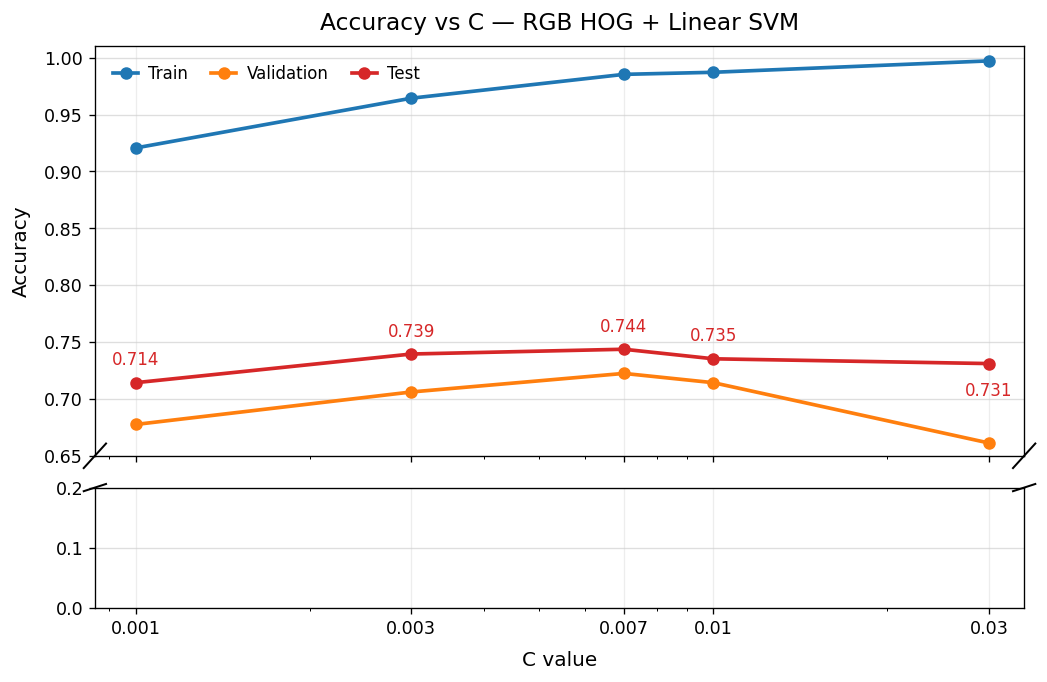

In [12]:
# We plot train, validation, and test accuracy across C values for the selected Linear SVM feature setting
# using a clean broken y-axis with two solid rectangular panels.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

from src.models.baselineModel import buildHogParamDict, buildSubsetFeatures

selectedImageSize = int(bestConfig["imageSize"])
selectedPixelsPerCell = (
    int(bestConfig["pixelsPerCell"][0]),
    int(bestConfig["pixelsPerCell"][1]),
)
selectedOrientations = int(bestConfig["orientations"])
selectedColorMode = str(bestConfig["colorMode"])

tuningSummaryDf = pd.read_csv(baselineSavedPathDict["tuningSummaryPath"])

selectedTrialRowsDf = tuningSummaryDf.loc[
    (
        (tuningSummaryDf["imageSize"] == selectedImageSize)
        & (tuningSummaryDf["pixelsPerCellX"] == selectedPixelsPerCell[0])
        & (tuningSummaryDf["pixelsPerCellY"] == selectedPixelsPerCell[1])
        & (tuningSummaryDf["orientations"] == selectedOrientations)
        & (tuningSummaryDf["colorMode"] == selectedColorMode)
    )
].copy()

selectedTrialRowsDf = selectedTrialRowsDf.sort_values("cValue").reset_index(drop=True)
cValueList = selectedTrialRowsDf["cValue"].astype(float).tolist()

strictManifestPath = projectConfig.manifestsDir / "modelingManifestStrict.csv"
strictManifestDf = pd.read_csv(strictManifestPath)

classToIndexMap = {
    className: classIndex
    for classIndex, className in enumerate(projectConfig.classNames)
}
indexToClassMap = {
    classIndex: className
    for classIndex, className in enumerate(projectConfig.classNames)
}

selectedHogParams = buildHogParamDict(
    orientations=selectedOrientations,
    pixelsPerCell=selectedPixelsPerCell,
)

trainFeatures, trainTargets, trainDf = buildSubsetFeatures(
    modelingManifestDf=strictManifestDf,
    subsetName="train",
    classToIndexMap=classToIndexMap,
    imageSize=selectedImageSize,
    hogParams=selectedHogParams,
    colorMode=selectedColorMode,
)

testFeatures, testTargets, testDf = buildSubsetFeatures(
    modelingManifestDf=strictManifestDf,
    subsetName="test",
    classToIndexMap=classToIndexMap,
    imageSize=selectedImageSize,
    hogParams=selectedHogParams,
    colorMode=selectedColorMode,
)

testAccuracyValueList = []

for cValue in cValueList:
    modelPipeline = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "classifier",
                LinearSVC(
                    C=float(cValue),
                    class_weight="balanced",
                    random_state=projectConfig.seed,
                    max_iter=10000,
                    tol=1e-3,
                    dual="auto",
                ),
            ),
        ]
    )

    modelPipeline.fit(trainFeatures, trainTargets)
    testPredictedIndices = modelPipeline.predict(testFeatures)

    testPredictedClassNames = [
        indexToClassMap[int(classIndex)]
        for classIndex in testPredictedIndices.tolist()
    ]

    testAccuracyValue = accuracy_score(
        testDf["className"],
        testPredictedClassNames,
    )

    testAccuracyValueList.append(float(testAccuracyValue))

plotDf = pd.DataFrame(
    {
        "cValue": cValueList,
        "trainAccuracy": selectedTrialRowsDf["trainAccuracy"].astype(float).tolist(),
        "valAccuracy": selectedTrialRowsDf["valAccuracy"].astype(float).tolist(),
        "testAccuracy": testAccuracyValueList,
    }
).sort_values("cValue").reset_index(drop=True)

xValues = plotDf["cValue"].astype(float).to_numpy()
trainValues = plotDf["trainAccuracy"].astype(float).to_numpy()
valValues = plotDf["valAccuracy"].astype(float).to_numpy()
testValues = plotDf["testAccuracy"].astype(float).to_numpy()

blueColor = "#1f77b4"
orangeColor = "#ff7f0e"
redColor = "#d62728"
gridColor = "#d0d0d0"

fig, (axTop, axBottom) = plt.subplots(
    2,
    1,
    figsize=(8.8, 6.0),
    sharex=True,
    gridspec_kw={"height_ratios": [3.4, 1.0], "hspace": 0.12},
)

for axisObject in [axTop, axBottom]:
    axisObject.plot(xValues, trainValues, marker="o", linewidth=2.2, markersize=6.5, color=blueColor, label="Train")
    axisObject.plot(xValues, valValues, marker="o", linewidth=2.2, markersize=6.5, color=orangeColor, label="Validation")
    axisObject.plot(xValues, testValues, marker="o", linewidth=2.2, markersize=6.5, color=redColor, label="Test")

    axisObject.grid(axis="y", color=gridColor, linewidth=0.8, alpha=0.7)
    axisObject.spines["top"].set_visible(True)
    axisObject.spines["right"].set_visible(True)
    axisObject.spines["left"].set_visible(True)
    axisObject.spines["bottom"].set_visible(True)

axTop.set_ylim(0.65, 1.01)
axBottom.set_ylim(0.00, 0.20)

axBottom.set_xscale("log")
axBottom.set_xlim(xValues.min() * 0.85, xValues.max() * 1.15)
axBottom.set_xticks(xValues)
axBottom.set_xticklabels([f"{currentValue:g}" for currentValue in xValues])

axTop.set_yticks(np.arange(0.65, 1.01, 0.05))
axBottom.set_yticks([0.0, 0.1, 0.2])

axTop.tick_params(axis="x", which="both", labelbottom=False)

breakKwargs = dict(color="black", clip_on=False, linewidth=1.2)
axTop.plot((-0.012, +0.012), (-0.03, +0.03), transform=axTop.transAxes, **breakKwargs)
axTop.plot((0.988, 1.012), (-0.03, +0.03), transform=axTop.transAxes, **breakKwargs)
axBottom.plot((-0.012, +0.012), (0.97, 1.03), transform=axBottom.transAxes, **breakKwargs)
axBottom.plot((0.988, 1.012), (0.97, 1.03), transform=axBottom.transAxes, **breakKwargs)

axTop.legend(
    loc="upper left",
    frameon=False,
    ncol=3,
    handlelength=1.5,
    columnspacing=1.4,
)

testYOffsetList = [0.012, 0.012, 0.012, 0.012, -0.016]
for xValue, yValue, yOffset in zip(xValues, testValues, testYOffsetList):
    axTop.text(
        xValue,
        yValue + yOffset,
        f"{yValue:.3f}",
        ha="center",
        va="bottom" if yOffset >= 0 else "top",
        fontsize=10,
        color=redColor,
    )

axTop.set_title("Accuracy vs C — RGB HOG + Linear SVM", pad=10)
axTop.set_ylabel("Accuracy")
axBottom.set_xlabel("C value")

fig.subplots_adjust(left=0.10, right=0.98, top=0.90, bottom=0.12)
plt.show()

In [13]:
# We save the approved Linear SVM accuracy-versus-C figure.

from src.utils import saveFigure

svmAccuracyCurvePath = saveFigure(
    fig=fig,
    outputDir=projectConfig.figuresDir / "hogLinearSvm",
    figureFileName="svm_accuracy_vs_c_broken_axis_clean.png",
    closeFigure=False,
)

print("Saved figure:", svmAccuracyCurvePath)

Saved figure: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/figures/hogLinearSvm/svm_accuracy_vs_c_broken_axis_clean.png


### Interpretation

This plot shows how accuracy changes across the tested `C` values for the selected RGB HOG feature setting in the final focused Linear SVM search.

The training curve increases steadily as `C` becomes larger, which means weaker regularization allows the SVM to fit the training set more strongly. The validation and test curves improve at first, but they do not keep improving indefinitely. Instead, both curves reach their strongest region in the low-`C` range and then flatten or decline again as regularization becomes weaker.

This indicates that the final SVM baseline has a meaningful sweet spot between underfitting and overfitting. In this focused search, that balance appears around `C = 0.007`, where validation accuracy reaches its best value and the test accuracy also stays strong. At the same time, the large gap between the training curve and the validation/test curves shows that stronger train fit alone is not enough and must be controlled by regularization.

Overall, this figure confirms that the final RGB HOG + Linear SVM model benefits from stronger regularization than the earlier broader search suggested. However, even after this improvement, Logistic Regression remains the stronger final classical baseline because it achieves better validation macro F1, which is our model-selection metric.